# 🫀 Proyecto 6 — Clasificación de Enfermedades Cardíacas con Redes Neuronales

---

## 📋 ¿Qué hace este proyecto?

Entrena una **red neuronal binaria** para predecir si un paciente tiene enfermedad cardíaca, usando el clásico [Heart Disease UCI Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease).

El target original tiene 5 niveles de severidad (0–4). Lo convertimos a **binario** (sano / enfermo) porque los grados intermedios tienen muy pocos ejemplos — una decisión estándar en la literatura clínica.

---

## 🔁 Flujo del proyecto

| Paso | Descripción |
|------|-------------|
| 🔧 **Preprocesamiento** | Imputación de nulos, escalado numérico, encoding categórico |
| 🔀 **Cross-validation** | 5-Fold estratificado para estimar performance real |
| 🔍 **Optuna** | Búsqueda de hiperparámetros optimizando **recall de enfermos** |
| 🧠 **Modelo final** | Red neuronal con los mejores parámetros encontrados |
| 📊 **Evaluación** | Umbral ajustado automáticamente para garantizar ≥ 95% de recall |

---

## ⚠️ Por qué no usamos accuracy como métrica principal

En diagnóstico médico, **un falso negativo** (enfermo clasificado como sano) es mucho más grave que un falso positivo. Por eso Optuna optimiza **recall** y el umbral de decisión se elige para garantizar detectar al menos el 95% de los enfermos, aunque eso implique más falsos positivos.

---

> 📁 Explicación detallada, decisiones de diseño y análisis de resultados en el [README del repositorio](#).

In [1]:
# ==========================================
# 0. INSTALACIONES (ejecutar una vez)
# ==========================================

!pip install scikeras optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.7 MB/s eta 0:00:00


In [22]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================

import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido en consola

from sklearn.datasets import load_iris
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import recall_score

from scikeras.wrappers import KerasClassifier  # puente Keras <-> sklearn

import shap

warnings.filterwarnings('ignore')


In [3]:
# ==========================================
# 2. DATASET
# ==========================================
import kagglehub

df = pd.read_csv('heart_disease_uci.csv')
print(df.columns)


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


- ID del paciente, no se usa
- age Edad en años
- sex 1 = masculino, 0 = femenino
- dataset Hospital de origen, no se usa
- cp Tipo de dolor de pecho (1=angina típica, 2=atípica, 3=no - anginal, 4=asintomático- )
- trestbps Presión arterial en reposo (mm Hg)
- chol Colesterol en sangre (mg/dl)
- fbs Azúcar en sangre en ayunas > 120 mg/dl (1=sí, 0=no)
- restecg Resultado del electrocardiograma en reposo (0, 1, 2) - thalch Frecuencia cardíaca máxima alcanzada
- exang Angina inducida por ejercicio (1=sí, 0=no)
- oldpeak Depresión del segmento ST inducida por ejercicio
- slope Pendiente del segmento ST en el pico del ejercicio
- ca Número de vasos principales coloreados por fluoroscopía (0–3)- thal Talasemia (tipo de defecto cardíaco)
- num Target — 0 = sin enfermedad, 1-4 = presencia de enfermedad

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [7]:
# Tratar con datos faltantes
df.groupby('dataset').count()



,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
dataset,,,,,,,,,,,,,,,
Cleveland,304,304,304,304,304,304,304,304,304,304,304,303,299,301,304
Hungary,293,293,293,293,292,270,285,292,292,292,293,104,3,28,293
Switzerland,123,123,123,123,121,123,48,122,122,122,117,106,5,71,123
VA Long Beach,200,200,200,200,144,193,193,200,147,147,144,98,2,34,200


In [8]:
# Para el análisis voy a quitar la columna "dataset"
df = df.drop(columns=['id','dataset'])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [9]:
# Datos faltantes

df['thal'].fillna(df['thal'].mode()[0], inplace=True)
df['ca'].fillna(df['ca'].mode()[0], inplace=True)
df['trestbps'].fillna(df['trestbps'].mean(), inplace=True)
df['chol'].fillna(df['chol'].mean(), inplace=True)
df['fbs'].fillna(df['fbs'].mode()[0], inplace=True)
df['restecg'].fillna(df['restecg'].mode()[0], inplace=True)
df['thalch'].fillna(df['thalch'].mean(), inplace=True)
df['exang'].fillna(df['exang'].mode()[0], inplace=True)
df['oldpeak'].fillna(df['oldpeak'].mean(), inplace=True)
df['slope'].fillna(df['slope'].mode()[0], inplace=True)

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2


In [20]:
# Procedo a separar datos para el entrenamiento

X = df.drop(columns=['num'])
y = df['num']

# Convertir a clasificación binaria: 0 = sano, 1 = enfermo
y = (df['num'] > 0).astype(int)

# Separar datos numéricos de categóricos

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y # Respeta proporción sanos/enfermos en el entrenamiento
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (736, 13) | Test: (184, 13)


In [14]:
# ==========================================
# 3. CROSS-VALIDATION SOBRE LA RED NEURONAL
# ==========================================

# Calculamos n_features ANTES de definir build_model
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

n_features = preprocessor.fit_transform(X_train).shape[1]
print(f'Features después del preprocesamiento: {n_features}')


def build_model():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Preprocesar X_train una sola vez
X_train_processed = preprocessor.transform(X_train)

# 5-Fold Stratified CV manual
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_processed, y_train)):
    X_fold_train = X_train_processed[train_idx]
    X_fold_val   = X_train_processed[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]

    model = build_model()
    model.fit(
        X_fold_train, y_fold_train,
        epochs=100,
        batch_size=16,
        verbose=0
    )

    _, acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(acc)
    print(f'Fold {fold+1}: {acc:.4f}')

cv_scores = np.array(cv_scores)
print(f'\nCV Scores por fold: {np.round(cv_scores, 4)}')
print(f'Media : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')  # std alto = modelo inestable

Features después del preprocesamiento: 21
Fold 1: 0.7770
Fold 2: 0.7687
Fold 3: 0.8367
Fold 4: 0.8231
Fold 5: 0.8571

CV Scores por fold: [0.777  0.7687 0.8367 0.8231 0.8571]
Media : 0.8125
Std   : 0.0343


In [15]:
# ==========================================
# 4. HYPERPARAMETER TUNING CON OPTUNA
# ==========================================

# Escalamos una sola vez fuera de Optuna para no repetirlo en cada trial
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)

X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)


def objective(trial):
    """Optuna llama esta función en cada trial.
    trial.suggest_* define el espacio de búsqueda."""

    # Optuna elige estos valores en cada trial
    n_units_1 = trial.suggest_categorical('n_units_1', [16, 32, 64])
    n_units_2 = trial.suggest_categorical('n_units_2', [8, 16, 32])
    dropout_1 = trial.suggest_float('dropout_1', 0.1, 0.4, step=0.1)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.3, step=0.1)
    lr        = trial.suggest_float('lr', 1e-4, 1e-2, log=True)  # espacio logarítmico

    model = Sequential([
        Dense(n_units_1, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(dropout_1),
        Dense(n_units_2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_2),
        Dense(1, activation='sigmoid') # cambio 3 por 1 y softmax por sigmoid
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy', # sparse_categorical_crossentropy cambiado por binary_crossentropy
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_processed, y_train,
        validation_split=0.20,
        epochs=150,
        callbacks=[early_stop],
        verbose=0
    )

    # Optuna minimiza por defecto, devolvemos val_loss (menor = mejor)
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print('\nMejores hiperparámetros encontrados:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor val_loss: {study.best_value:.4f}')


Mejores hiperparámetros encontrados:
  n_units_1: 64
  n_units_2: 32
  dropout_1: 0.1
  dropout_2: 0.1
  lr: 0.00011160530493550503

Mejor val_loss: 0.3649


In [16]:
# ==========================================
# 5. MODELO FINAL CON LOS MEJORES PARAMS
# ==========================================

best = study.best_params

final_model = Sequential([
    Dense(best['n_units_1'], activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(best['dropout_1']),
    Dense(best['n_units_2'], activation='relu'),
    BatchNormalization(),
    Dropout(best['dropout_2']),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best['lr']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_processed, y_train,
    validation_split=0.20,
    epochs=300,
    callbacks=[early_stop],
    verbose=1
)

loss, acc = final_model.evaluate(X_test_processed, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')

Epoch 1/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4745 - loss: 0.9359 - val_accuracy: 0.5676 - val_loss: 0.7016
Epoch 2/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5289 - loss: 0.8446 - val_accuracy: 0.5878 - val_loss: 0.6898
Epoch 3/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5663 - loss: 0.7883 - val_accuracy: 0.5946 - val_loss: 0.6752
Epoch 4/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5493 - loss: 0.7878 - val_accuracy: 0.6014 - val_loss: 0.6595
Epoch 5/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5969 - loss: 0.7324 - val_accuracy: 0.6486 - val_loss: 0.6442
Epoch 6/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6241 - loss: 0.6968 - val_accuracy: 0.6689 - val_loss: 0.6301
Epoch 7/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6310 - loss: 0.6778 - val_accuracy: 0.6757 - val_loss: 0.6141
Epoch 8/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6531 - loss: 0.6448 - val_accuracy: 0.68

# - Los mejores resultados van a estar asociados con un Recall alto en el contexto de la medicina.

# - Por esa razón voy a buscar un threshold que me garantice un 95%

In [17]:
## Garantiza un buen recall! 0.95

# 1. Predecir probabilidades
y_pred_prob = final_model.predict(X_test_processed).flatten()

# 2. Calcular curva ROC (de acá sale thresholds)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

y_test_arr = y_test.to_numpy()  # convertir una sola vez

resultados = []
for thresh in thresholds:
    y_tmp = (y_pred_prob > thresh).astype(int).flatten()
    recall_enfermos = recall_score(y_test_arr, y_tmp)
    fpr_tmp = ((y_tmp == 1) & (y_test_arr == 0)).sum() / (y_test_arr == 0).sum()
    resultados.append((thresh, recall_enfermos, fpr_tmp))

candidatos = [(t, r, f) for t, r, f in resultados if r >= 0.95]
mejor = min(candidatos, key=lambda x: x[2])
best_threshold = mejor[0]
print(f'Umbral: {best_threshold:.3f} | Recall enfermos: {mejor[1]:.3f} | FPR: {mejor[2]:.3f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Umbral: 0.267 | Recall enfermos: 0.951 | FPR: 0.329


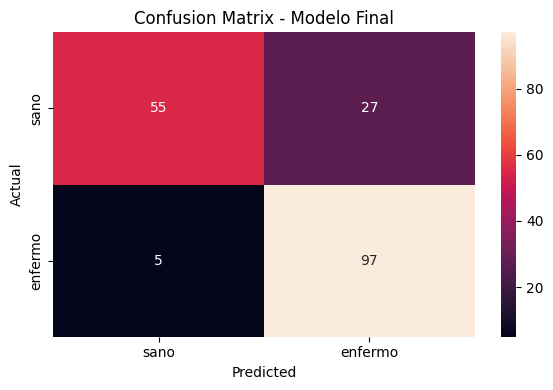

              precision    recall  f1-score   support

        sano       0.92      0.67      0.77        82
     enfermo       0.78      0.95      0.86       102

    accuracy                           0.83       184
   macro avg       0.85      0.81      0.82       184
weighted avg       0.84      0.83      0.82       184



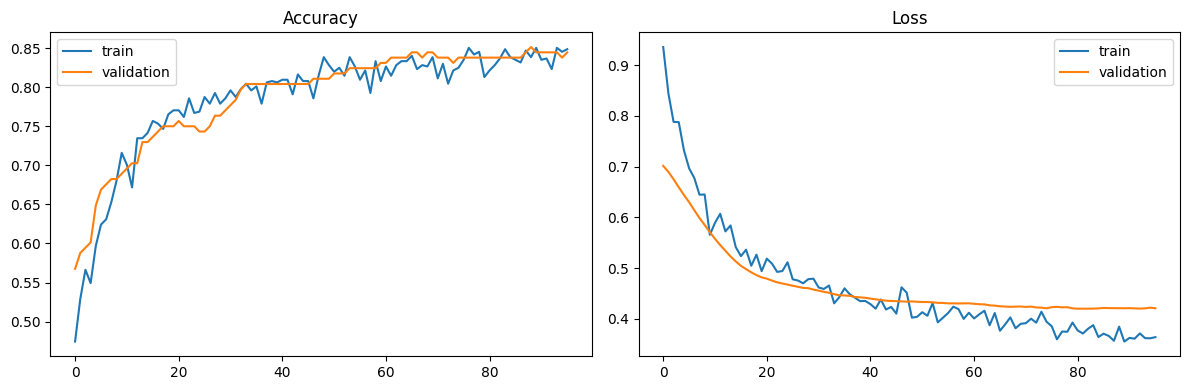

In [18]:
# ==========================================
# 6. EVALUACIÓN COMPLETA
# ==========================================

# y_pred_prob = final_model.predict(X_test_processed)
y_pred = (y_pred_prob > best_threshold).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['sano', 'enfermo'],
            yticklabels=['sano', 'enfermo'])
plt.title('Confusion Matrix - Modelo Final')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['sano', 'enfermo']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Umbral óptimo: 0.564 | AUC: 0.9187


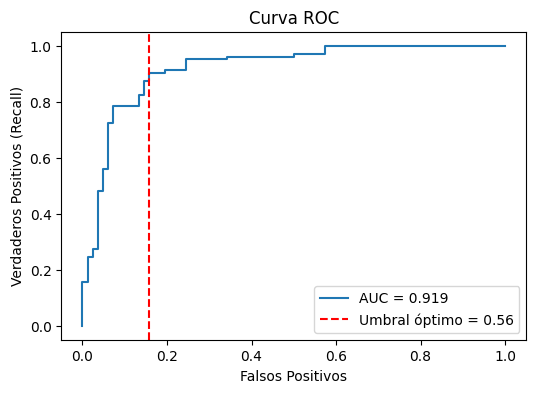

In [19]:
y_pred_prob = final_model.predict(X_test_processed).flatten()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Buscar el umbral que maximiza TPR - FPR (índice de Youden)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'Umbral óptimo: {optimal_threshold:.3f} | AUC: {auc:.4f}')

# Graficar
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.axvline(fpr[optimal_idx], color='red', linestyle='--', label=f'Umbral óptimo = {optimal_threshold:.2f}')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

y_pred = (y_pred_prob > optimal_threshold).astype(int)

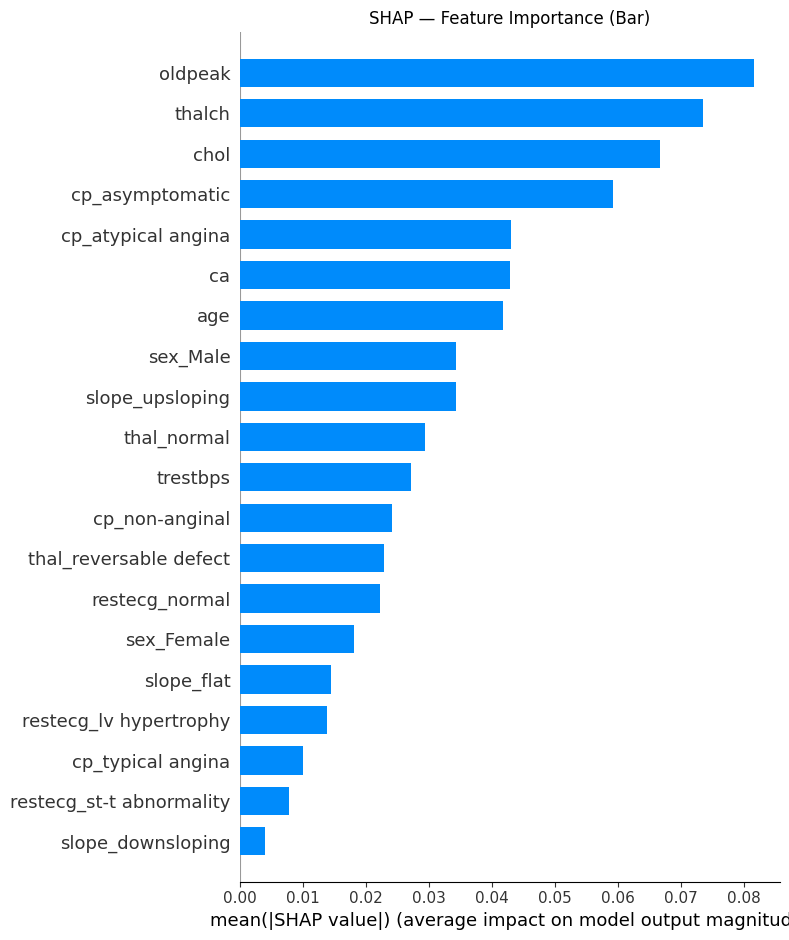

In [30]:
# ==========================================
# 7. ANÁLISIS SHAP
# ==========================================

import shap

# SHAP necesita un explainer compatible con Keras
# DeepExplainer es el indicado para redes neuronales
explainer = shap.DeepExplainer(final_model, X_train_processed[:100])

# Calcular valores SHAP sobre el test set
shap_values = explainer.shap_values(X_test_processed)

# Aplanar la dimensión extra
shap_vals = shap_values[:, :, 0]  # (184, 21, 1) → (184, 21)

# Recuperar nombres de features después del preprocesamiento
num_feature_names = list(num_cols)
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)
feature_names = num_feature_names + cat_feature_names

# --- Bar plot: importancia global ---
plt.figure()
shap.summary_plot(
    shap_vals,
    X_test_processed,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Feature Importance (Bar)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


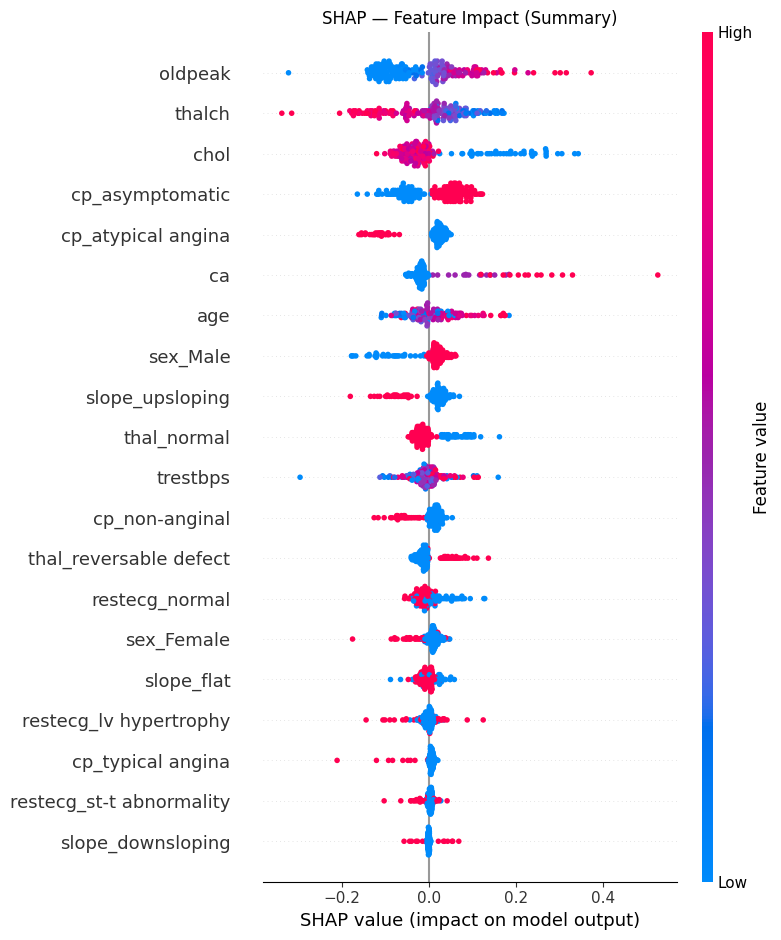

In [29]:
# --- Summary plot: dirección del impacto ---
plt.figure()
shap.summary_plot(
    shap_vals,
    X_test_processed,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP — Feature Impact (Summary)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cómo leer el SHAP Summary Plot

| Elemento | Significado |
|----------|-------------|
| 📍 **Cada punto** | Un paciente del test set |
| ↔️ **Eje X** | Impacto en la predicción: izquierda = empuja a **sano**, derecha = empuja a **enfermo** |
| 🔴 **Color rosa/rojo** | Valor alto de esa feature |
| 🔵 **Color azul** | Valor bajo de esa feature |

> ⚠️ SHAP muestra lo que el modelo aprendió de *estos* datos — no necesariamente la verdad clínica universal.

## 🔍 Análisis de las Features más Importantes

| Feature | Patrón | Interpretación |
|---------|--------|----------------|
| 🥇 **oldpeak** | 🔵 izquierda · 🔴 derecha | Valores altos de depresión del segmento ST → **enfermo** |
| 🥈 **thalch** | 🔴 izquierda · 🔵 derecha | Frecuencia cardíaca máxima alta → **sano** *(corazones sanos llegan más lejos)* |
| 🥉 **cp_asymptomatic** | 🔴 derecha | Dolor de pecho asintomático → **peor signo** *(la ausencia de síntomas suele indicar enfermedad severa)* |
| **ca** | 🔴 muy a la derecha | Más vasos obstruidos → **fuertemente enfermo** *(feature más directamente diagnóstica)* |

---

## ⚠️ El caso anómalo: `chol`

A diferencia de lo esperado clínicamente, el modelo muestra:

- 🔴 Rosados (colesterol **alto**) → levemente a la izquierda → empuja a **sano**
- 🔵 Azules (colesterol **bajo**) → dispersos a la derecha → empujan a **enfermo**

Esto se llama **correlación espuria** — el modelo encontró un patrón en los datos que no refleja causalidad real. Posibles causas:

> 📦 **Dataset chico** — 900 pacientes de múltiples hospitales. Los pacientes más enfermos probablemente ya estaban medicados, con el colesterol artificialmente controlado.

> 🤖 **El modelo no entiende medicina** — solo ve números y correlaciones. No sabe que el colesterol *causa* enfermedad, solo ve lo que aparece en estos registros.

> 🔀 **Confounding** — una tercera variable puede explicar la relación. Por ejemplo, la edad: pacientes mayores tienen más enfermedad cardíaca *y* más tratamiento del colesterol simultáneamente.

## ✅ Conclusiones

| Métrica | Resultado |
|--------|-----------|
| 🎯 **AUC** | 0.919 |
| 🔍 **Recall enfermos** | ≥ 95% |
| ⚖️ **Umbral de decisión** | ~0.26 |

- 🏥 Se priorizó **minimizar falsos negativos** (enfermos clasificados como sanos) por sobre el accuracy global — en diagnóstico médico, este error tiene consecuencias inaceptables.
- 📈 El umbral se ajustó automáticamente vía curva ROC para garantizar el recall objetivo, a costa de aumentar los falsos positivos.
- 📉 Las curvas de entrenamiento no muestran overfitting severo — train y validation convergen razonablemente.

> 📦 Con ~900 registros los resultados son sólidos, pero más datos mejorarían recall y precisión **simultáneamente** — actualmente existe un trade-off inevitable entre ambos.

In [21]:
import joblib

# Guardar el preprocessor (scaler + encoder)
joblib.dump(preprocessor, 'preprocessor.pkl')

# Guardar el modelo de Keras
final_model.save('heart_disease_model.keras')

print('Modelo y preprocessor guardados.')

Modelo y preprocessor guardados.


In [ ]:
import joblib
import tensorflow as tf

preprocessor = joblib.load('preprocessor.pkl')
final_model = tf.keras.models.load_model('heart_disease_model.keras')